In [2]:
from main.scheduler import EDMScheduler
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch

In [3]:
num_steps = 5
edmsampler1 = EDMScheduler(num_steps)
t = edmsampler1.get_discrete_time_steps(num_steps)
sigma = edmsampler1.get_sigma(t)

In [4]:
#Load a scheduler using a config file
daps_config_yaml = 'configs/daps_config/edm_daps.yaml'
daps_config = OmegaConf.load(daps_config_yaml)

In [5]:
#Load a model using a config file
from model import get_model
model_config_yaml = 'configs/model/ffhq256ldm.yaml'
model_config = OmegaConf.load(model_config_yaml)
model = get_model(**model_config)

/home/jovyan/dl_env/dl_env1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model from checkpoints/ldm_ffhq256.pt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 274.06 M params.
Keeping EMAs of 370.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 3, 64, 64) = 12288 dimensions.
making attention of type 'vanilla' with 512 in_channels
Training LatentDiffusion as an unconditional model.


In [6]:
#Load a dataset using a config file
from data import get_dataset
dataset_config_yaml = 'configs/data/ffhq.yaml'
dataset_config = OmegaConf.load(dataset_config_yaml)
dataset = get_dataset(**dataset_config)
images = dataset.get_data(5)

In [7]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images, target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()




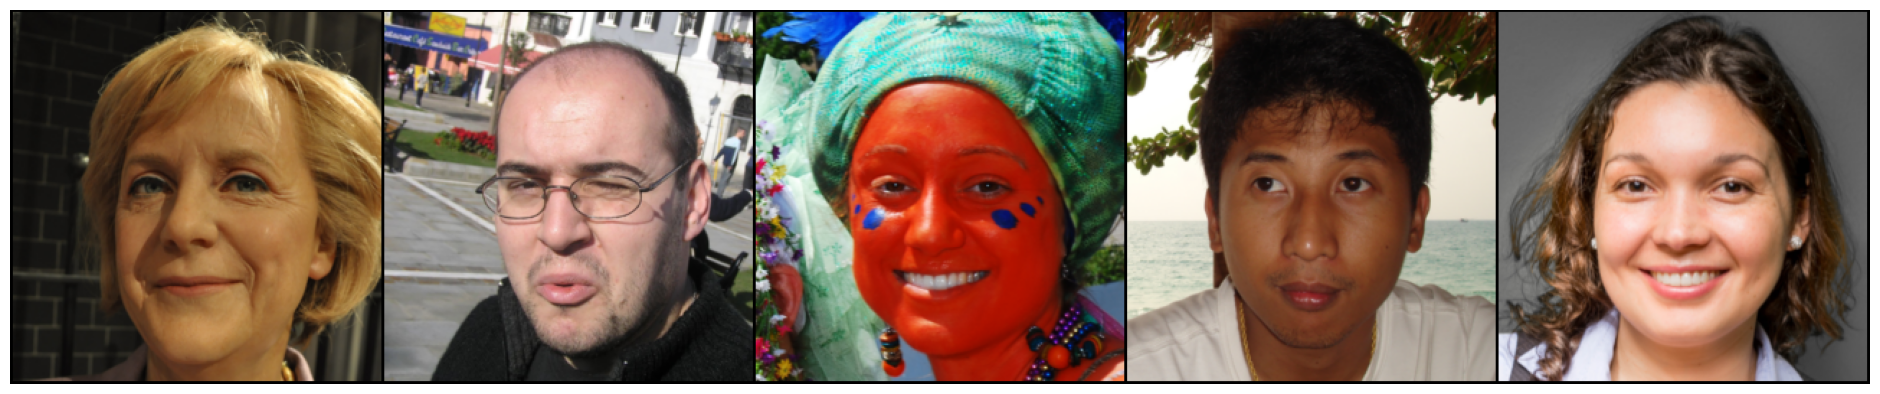

In [8]:
visualize_grid(images, nrow=10)

In [9]:
img1 = images[0]
model.get_in_shape()

(3, 64, 64)

In [10]:
#To check if pfode.py is working
from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (5, *model.get_in_shape()))
z_T = pf_ode.gaussian_prior_x_T(5)
z_0 = pf_ode.solve(z_T)
x_0 = model.decode(z_0)

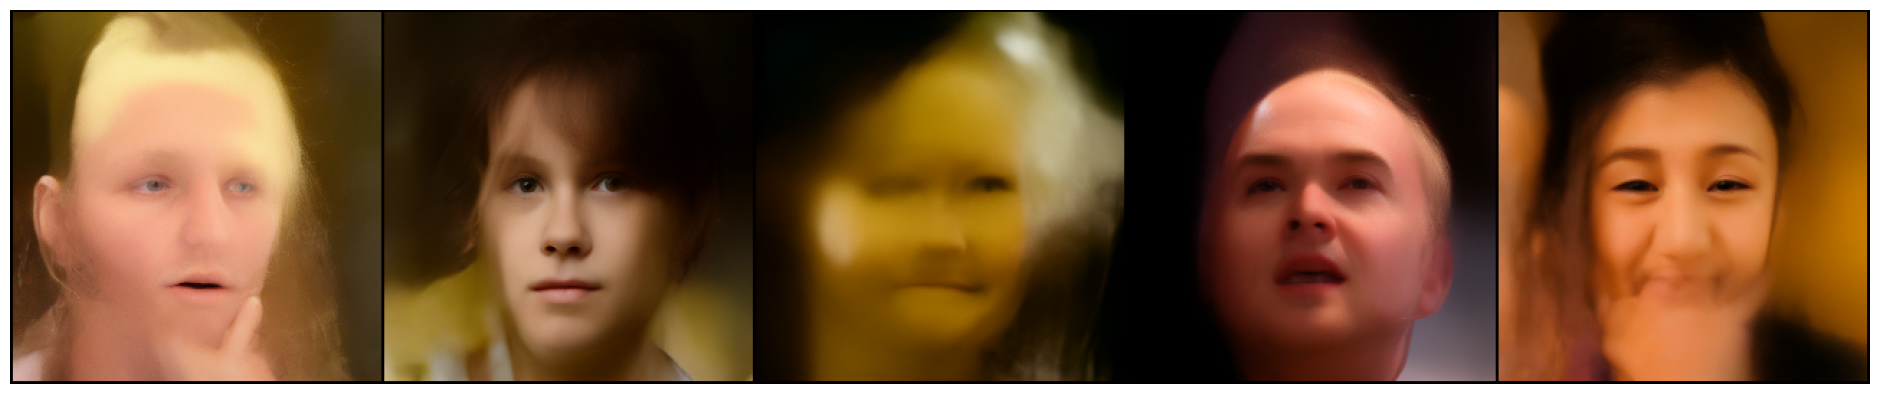

In [11]:
visualize_grid(x_0, nrow=5)

In [12]:
#Load an operator using a config file
task_config_yaml = 'configs/task/phase_retrieval.yaml'
task_group = 'ldm'
task_config = OmegaConf.load(task_config_yaml)
mcmc_sampler_config = task_config[task_group].mcmc_sampler_config
operator_config = task_config[task_group].operator


In [13]:
from forward_operator import get_operator
operator = get_operator(**operator_config)
measurement = operator.measure(images)

In [14]:
from torch.nn.functional import interpolate

def resize(y, x, task_name):
    if y.shape != x.shape:
        ry = interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)
    else:
        ry = y
    if task_name == 'phase_retrieval':
        def norm_01(y):
            tmp = (y - y.mean()) / y.std()
            tmp = tmp.clip(-0.5, 0.5) * 3
            return tmp

        ry = norm_01(ry) * 2 - 1
    return ry

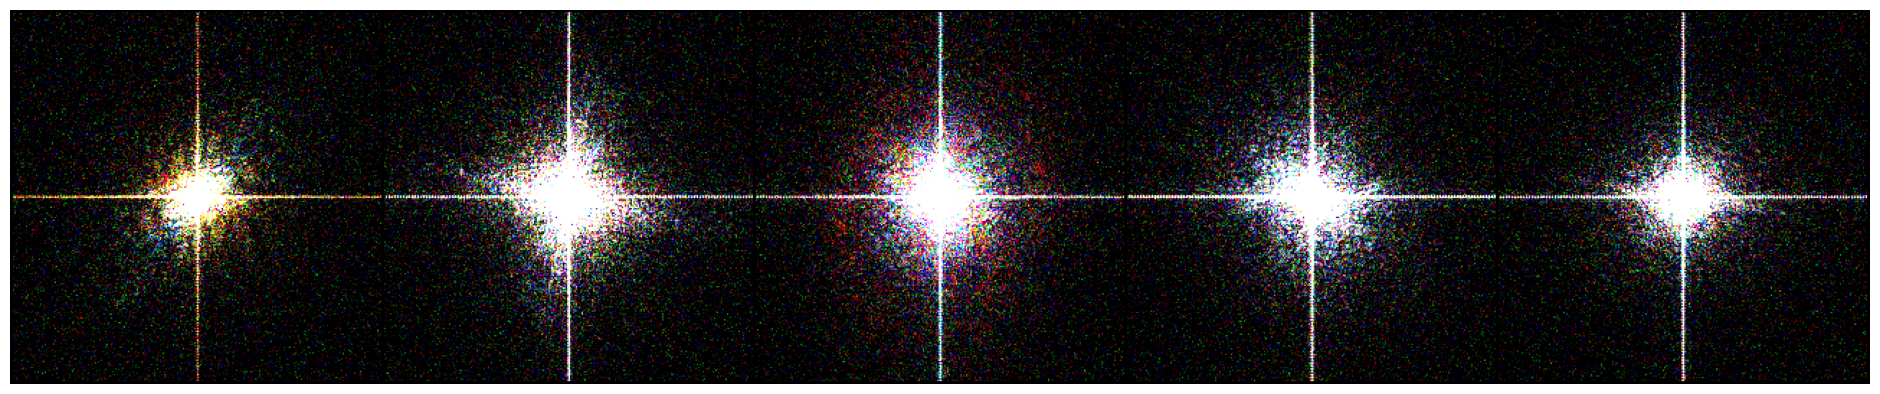

In [15]:
#Measurement works
resized_measurement = resize(measurement, images, operator_config.name)
visualize_grid(resized_measurement, nrow=5)

In [16]:
#To check if DAPS is working
from daps_sampler import LatentDAPS
latentdaps = LatentDAPS(daps_config['annealing_scheduler_config'], daps_config['diffusion_scheduler_config'], mcmc_sampler_config)
z_init = pf_ode.gaussian_prior_x_T(5)
x_final = latentdaps.latent_daps_sample(model, z_init, operator, measurement)

  0%|          | 0/30 [00:00<?, ?it/s]/home/jovyan/dl_env/dl_env1/lib/python3.11/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 30/30 [09:54<00:00, 19.83s/it]


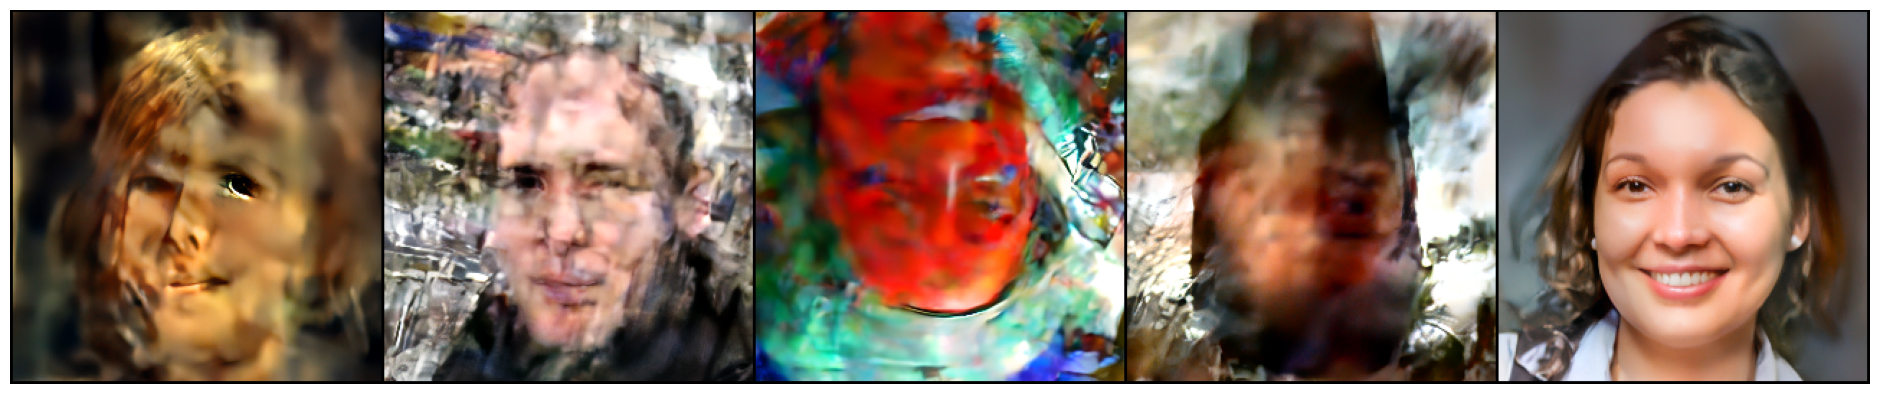

In [17]:
visualize_grid(x_final, nrow=5)